In [9]:
# Установка зависимостей (запустите один раз)
# %pip install -r requirements.txt

### Простой агент

Этот ноутбук запускает ReAct-агента
Бэкенд (GigaChat или LM Studio) настраивается в `config.yaml`.

In [10]:
# Импорты
import yaml
from pprint import pprint
from langgraph.prebuilt import create_react_agent
from tools.tools import tools
from connections.clients import get_llm_client

In [11]:
# Загрузка конфигурации
with open('config.yaml', 'r', encoding='utf-8') as f:
    config = yaml.safe_load(f)

print(f"Активный бэкенд: {config['active_backend']}")
pprint(config)

Активный бэкенд: lmstudio
{'active_backend': 'lmstudio',
 'backends': {'gigachat': {'env_vars': {'access_token': 'JPY_API_TOKEN',
                                        'base_url': 'GIGACHAT_API_URL'},
                           'model': 'GigaChat-2'},
              'lmstudio': {'base_url': 'http://localhost:1234/v1',
                           'model': 'openai/gpt-oss-20b'}}}


In [12]:
# Создание LLM клиента
backend = config['active_backend']
llm = get_llm_client(backend, config)
print(f"LLM клиент создан: {type(llm).__name__}")

LLM клиент создан: ChatOpenAI


In [13]:
# Создание ReAct-агента
agent_executor = create_react_agent(
    model=llm,
    tools=tools
)
print("Агент создан успешно!")

Агент создан успешно!


C:\Users\accordij\AppData\Local\Temp\ipykernel_19472\1833556789.py:2: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  agent_executor = create_react_agent(


### Тестовые запросы

In [14]:
# Тест 1: Простое вычисление
query1 = "Сколько будет 52 умножить на 48?"
print(f"Запрос: {query1}\n")

messages = agent_executor.invoke({'messages': [query1]})['messages']
pprint(messages)
print(f"\nОтвет агента: {messages[-1].content}")

Запрос: Сколько будет 52 умножить на 48?

[HumanMessage(content='Сколько будет 52 умножить на 48?', additional_kwargs={}, response_metadata={}, id='c3ff9e34-6a59-45ca-aa97-8028a44e39f4'),
 AIMessage(content='', additional_kwargs={'tool_calls': [{'id': '229176836', 'function': {'arguments': '{"expression":"52 * 48"}', 'name': 'calculator'}, 'type': 'function'}], 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 39, 'prompt_tokens': 469, 'total_tokens': 508, 'completion_tokens_details': None, 'prompt_tokens_details': None}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'openai/gpt-oss-20b', 'id': 'chatcmpl-ahsa2x8txln21uiu7fks4', 'service_tier': None, 'finish_reason': 'tool_calls', 'logprobs': None}, id='run--019be49a-3822-7a93-935b-1ac22a79ff77-0', tool_calls=[{'name': 'calculator', 'args': {'expression': '52 * 48'}, 'id': '229176836', 'type': 'tool_call'}], usage_metadata={'input_tokens': 469, 'output_tokens': 39, 'total_tokens': 508, 'input_token_de

In [15]:
# Тест 3: Проверка работы калькулятора напрямую
from tools.tools import calculator

print("Тест функции калькулятора напрямую:")
test_expr = "2 ** 10"
result = calculator.invoke(test_expr)
print(f"{test_expr} = {result}")

Тест функции калькулятора напрямую:
2 ** 10 = 1024


---

## Агент с графом состояний

Ниже используется StateGraph с двумя состояниями:
- **Work State**: основная работа с полным набором инструментов (calculator, ask_human, think, memory)
- **Summarize State**: подведение итогов с рефлексией (summarize, memory)

Переходы:
- Work → Work (циклически, пока задача не решена)
- Work → Summarize (когда агент говорит "ЗАДАЧА_РЕШЕНА")
- Summarize → END

In [16]:
# Импорт агента (построенного через движок)
from my_agent import build_my_agent
from tools.tools import tools

# Подготовка инструментов
tools_dict = {tool.name: tool for tool in tools}

# Создание графа состояний
print("🔧 Создание графа состояний через движок...")
graph_agent = build_my_agent(llm, tools_dict)
print("✓ Граф состояний создан успешно!")
print(f"  Инструментов доступно: {len(tools_dict)}")

🔧 Создание графа состояний через движок...
✓ Граф состояний создан успешно!
  Инструментов доступно: 5


In [17]:
# Визуализация структуры агента
from my_agent.graph import visualize_graph

print(visualize_graph(llm, tools_dict))

📊 Граф агента:

Состояния:
  • work (entry)
    Инструменты: calculator, ask_human, think, memory
    Описание: Основное рабочее состояние с полным набором инструментов
  • summarize
    Инструменты: summarize, memory
    Описание: Финальное состояние для рефлексии и подведения итогов

Переходы:
  • work → summarize (условный)
    Переход из рабочего состояния в состояние подведения итогов. Срабатывает, когда агент говорит 'ЗАДАЧА_РЕШЕНА'. Если условие не выполнено, агент остается в Work и продолжает работу.
  • summarize → END (условный)
    Безусловное завершение работы после подведения итогов. Состояние Summarize всегда переходит в END.


### Тестовые сценарии с графом состояний

In [18]:
# Тест 1: Простое вычисление (без уточнений)
print("=" * 60)
print("ТЕСТ 1: Простое вычисление")
print("=" * 60)

query = "Вычисли 25 * 4 и сохрани результат в память"

result = graph_agent.invoke({
    'messages': [query],
    'memory': {}
})

print("\n" + "=" * 60)
print("РЕЗУЛЬТАТ:")
print("=" * 60)
print(f"\nПоследнее сообщение: {result['messages'][-1].content}")
print(f"\nПамять агента: {result.get('memory', {})}")

ТЕСТ 1: Простое вычисление

РЕЗУЛЬТАТ:

Последнее сообщение: ЗАДАЧА_РЕШЕНА

Память агента: {'result_25_times_4': '100'}


In [19]:
# Тест 2: Вычисление с уточнениями
# Агент должен задать вопросы через инструмент ask_human
print("\n" + "=" * 60)
print("ТЕСТ 2: Вычисление площади (потребуются уточнения)")
print("=" * 60)
print("Агент будет задавать вопросы. Отвечайте в консоли.")
print("Пример ответов: длина = 10, ширина = 5")
print("=" * 60 + "\n")

query2 = "Вычисли площадь прямоугольника. Если не хватает данных, спроси у пользователя."

result2 = graph_agent.invoke({
    'messages': [query2],
    'memory': {}
})

print("\n" + "=" * 60)
print("РЕЗУЛЬТАТ:")
print("=" * 60)
print(f"\nПоследнее сообщение: {result2['messages'][-1].content}")
print(f"\nПамять агента: {result2.get('memory', {})}")


ТЕСТ 2: Вычисление площади (потребуются уточнения)
Агент будет задавать вопросы. Отвечайте в консоли.
Пример ответов: длина = 10, ширина = 5


🤔 Вопрос агента: Укажите длину и ширину прямоугольника (в формате 'длина ширина', например '5 3').

РЕЗУЛЬТАТ:

Последнее сообщение: Площадь прямоугольника равна \(100 \times 2{,}39 = 239{,}0\) квадратных единиц.

ЗАДАЧА_РЕШЕНА

Память агента: {'result_25_times_4': '100'}


In [20]:
# Тест 3: Демонстрация инструментов think и memory
print("\n" + "=" * 60)
print("ТЕСТ 3: Использование инструментов think и memory")
print("=" * 60)

query3 = """Реши задачу пошагово:
1. Используй инструмент think чтобы поразмышлять над задачей
2. Вычисли (15 + 25) * 2
3. Сохрани промежуточные результаты в память
4. В конце скажи ЗАДАЧА_РЕШЕНА"""

result3 = graph_agent.invoke({
    'messages': [query3],
    'memory': {}
})

print("\n" + "=" * 60)
print("РЕЗУЛЬТАТ:")
print("=" * 60)
print(f"\nПоследнее сообщение: {result3['messages'][-1].content}")
print(f"\nПамять агента: {result3.get('memory', {})}")


ТЕСТ 3: Использование инструментов think и memory

💭 Размышление агента: We need to compute (15+25)*2 = 40*2 =80

РЕЗУЛЬТАТ:

Последнее сообщение: ЗАДАЧА_РЕШЕНА

Память агента: {'result_25_times_4': '100', 'intermediate_result': '80'}


### Визуализация графа состояний

Структура графа (Mermaid):
---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	work(work)
	summarize(summarize)
	__end__([<p>__end__</p>]):::last
	__start__ --> work;
	summarize -. &nbsp;END&nbsp; .-> __end__;
	work -.-> summarize;
	summarize -.-> summarize;
	work -.-> work;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



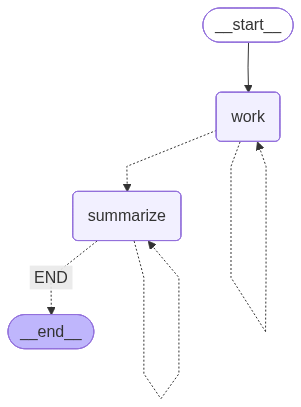

In [21]:
# Визуализация структуры графа
try:
    from IPython.display import Image, display
    
    # Получаем mermaid-диаграмму графа
    mermaid_diagram = graph_agent.get_graph().draw_mermaid()
    print("Структура графа (Mermaid):")
    print(mermaid_diagram)
    
    # Если установлен graphviz, можно получить PNG
    try:
        png_data = graph_agent.get_graph().draw_mermaid_png()
        display(Image(png_data))
    except Exception:
        print("\nДля визуализации PNG установите: pip install pygraphviz")
        
except Exception as e:
    print(f"Визуализация недоступна: {e}")